# 📧 Email Spam Detection with Machine Learning
Binary text classification using TF-IDF and Machine Learning.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re,string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,classification_report

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from wordcloud import WordCloud


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load Dataset

In [15]:
df=pd.read_csv("spam.csv",encoding='latin1')
df=df[['v1','v2']]
df.columns=['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Dataset Information

In [16]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df['label'].value_counts())

percent=(df['label'].value_counts(normalize=True)*100).round(2)
print(percent)


(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label      0
message    0
dtype: int64
label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


## Class Distribution

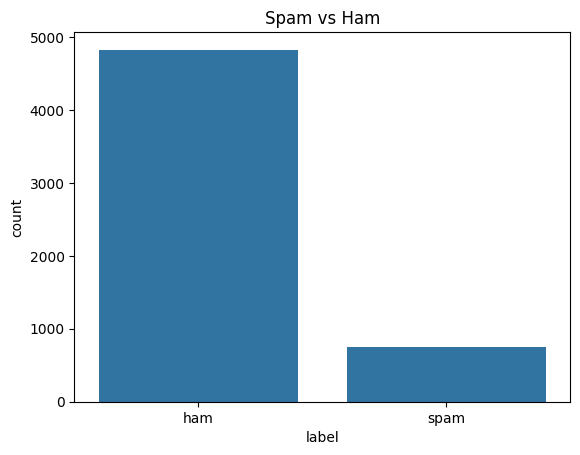

In [17]:
sns.countplot(x='label',data=df)
plt.title("Spam vs Ham")
plt.show()

## Text Preprocessing

In [18]:
stop_words=set(stopwords.words('english'))
stemmer=PorterStemmer()

def preprocess(text):
    text=text.lower()
    text=re.sub(r'[^a-zA-Z ]',' ',text)
    words=text.split()
    words=[stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_message']=df['message'].apply(preprocess)
df[['message','clean_message']].head()


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


## TF-IDF Vectorizer

**TF-IDF (Term Frequency–Inverse Document Frequency)** converts text into numerical features.

- **Term Frequency (TF):** Measures how frequently a word appears in a document.
- **Inverse Document Frequency (IDF):** Reduces the importance of words that appear in many documents.
- Words that are frequent in one message but rare across the dataset receive higher weights.


In [19]:
tfidf=TfidfVectorizer(max_features=5000)
X=tfidf.fit_transform(df['clean_message'])
y=df['label']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)


## Multinomial Naive Bayes

In [20]:
nb=MultinomialNB()
nb.fit(X_train,y_train)
nb_pred=nb.predict(X_test)

print("Accuracy:",accuracy_score(y_test,nb_pred))
print("Precision:",precision_score(y_test,nb_pred,pos_label='spam'))
print("Recall:",recall_score(y_test,nb_pred,pos_label='spam'))
print("F1:",f1_score(y_test,nb_pred,pos_label='spam'))
print(classification_report(y_test,nb_pred))


Accuracy: 0.9695067264573991
Precision: 0.9914529914529915
Recall: 0.7785234899328859
F1: 0.8721804511278195
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.78      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



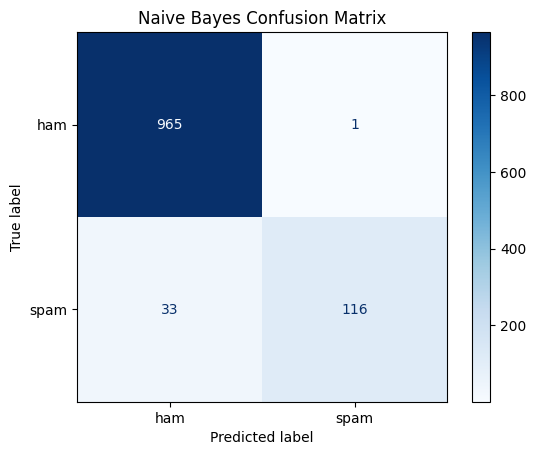

In [21]:
ConfusionMatrixDisplay.from_predictions(y_test,nb_pred,cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

## Logistic Regression

In [22]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)

print("Accuracy:",accuracy_score(y_test,lr_pred))
print("Precision:",precision_score(y_test,lr_pred,pos_label='spam'))
print("Recall:",recall_score(y_test,lr_pred,pos_label='spam'))
print("F1:",f1_score(y_test,lr_pred,pos_label='spam'))
print(classification_report(y_test,lr_pred))


Accuracy: 0.9650224215246637
Precision: 0.9910714285714286
Recall: 0.7449664429530202
F1: 0.8505747126436781
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



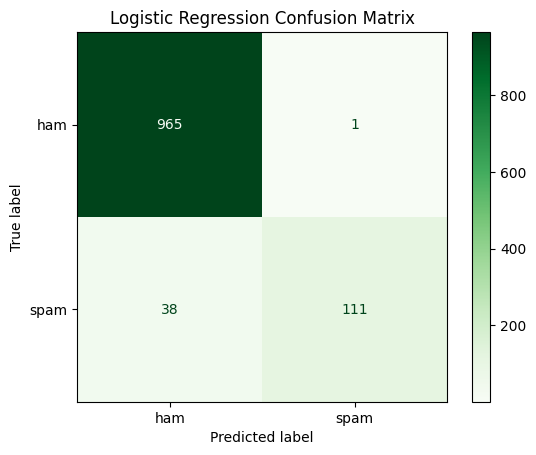

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test,lr_pred,cmap='Greens')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Model Comparison

In [24]:
results=pd.DataFrame({
'Model':['Naive Bayes','Logistic Regression'],
'Accuracy':[accuracy_score(y_test,nb_pred),accuracy_score(y_test,lr_pred)],
'Precision':[precision_score(y_test,nb_pred,pos_label='spam'),precision_score(y_test,lr_pred,pos_label='spam')],
'Recall':[recall_score(y_test,nb_pred,pos_label='spam'),recall_score(y_test,lr_pred,pos_label='spam')],
'F1 Score':[f1_score(y_test,nb_pred,pos_label='spam'),f1_score(y_test,lr_pred,pos_label='spam')]
})
results


,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.969507,0.991453,0.778523,0.872180
1,Logistic Regression,0.965022,0.991071,0.744966,0.850575


## Why is Recall Important for Spam Detection?

Recall measures how many actual spam emails are correctly identified by the model.

A low recall means many spam emails are incorrectly classified as legitimate (ham). Missing spam emails can expose users to phishing attacks, scams, malware, or unwanted advertisements.

Therefore, spam detection systems aim for a high recall so that as many spam messages as possible are detected while maintaining a reasonable precision.


## Bonus: Word Clouds

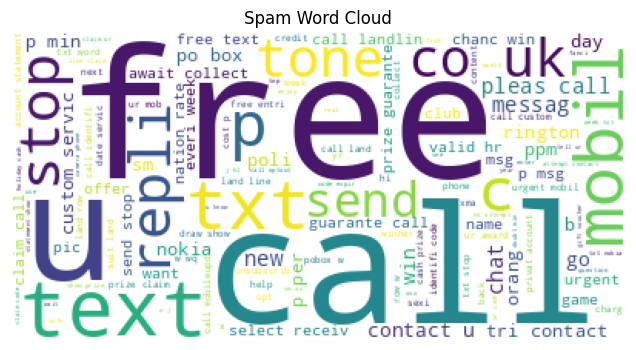

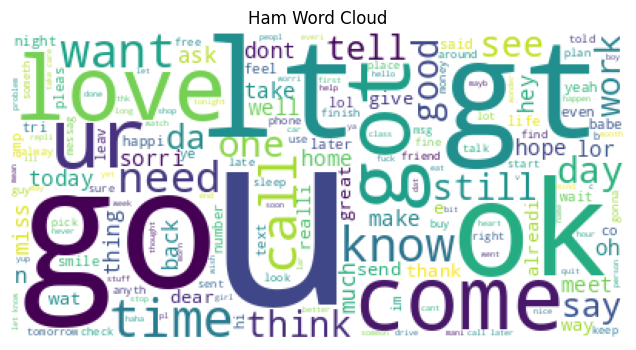

In [25]:
spam=' '.join(df[df.label=='spam']['clean_message'])
ham=' '.join(df[df.label=='ham']['clean_message'])

plt.figure(figsize=(8,4))
plt.imshow(WordCloud(background_color='white').generate(spam))
plt.axis('off')
plt.title('Spam Word Cloud')
plt.show()

plt.figure(figsize=(8,4))
plt.imshow(WordCloud(background_color='white').generate(ham))
plt.axis('off')
plt.title('Ham Word Cloud')
plt.show()


## Best Performing Model

In [26]:
best=results.sort_values('F1 Score',ascending=False).iloc[0]
print(best)

print(f'''
Best Performing Model: {best["Model"]}

Justification:
- Highest F1 Score
- Strong Precision and Recall
- Best overall spam classification performance
''')


Model        Naive Bayes
Accuracy        0.969507
Precision       0.991453
Recall          0.778523
F1 Score         0.87218
Name: 0, dtype: object

Best Performing Model: Naive Bayes

Justification:
- Highest F1 Score
- Strong Precision and Recall
- Best overall spam classification performance

